Dataset shape: (300, 20)
Shape setelah encoding: (300, 20)
Train: 240, Test: 60
Distribusi train:
 Tinggi    190
Netral     45
Rendah      5
Name: count, dtype: int64
Distribusi test:
 Tinggi    48
Netral    11
Rendah     1
Name: count, dtype: int64
Regresi Tanpa Scaler: RMSE=4.64, R²=0.7226
Regresi Dengan Scaler: RMSE=4.64, R²=0.7234
Classifier Tanpa Scaler: Akurasi=0.8500, F1 Macro=0.4641
Classifier Dengan Scaler: Akurasi=0.8500, F1 Macro=0.4641

===== Classification Report Model Terbaik =====
              precision    recall  f1-score   support

      Rendah       0.00      0.00      0.00         1
      Netral       0.67      0.36      0.47        11
      Tinggi       0.87      0.98      0.92        48

    accuracy                           0.85        60
   macro avg       0.51      0.45      0.46        60
weighted avg       0.82      0.85      0.82        60



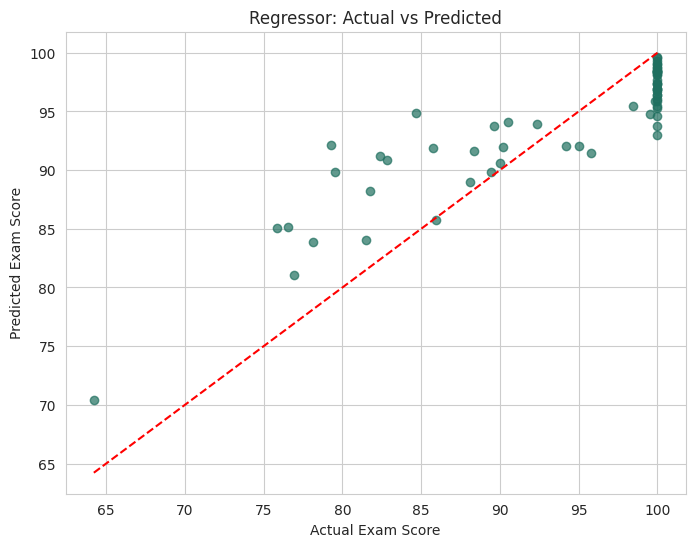

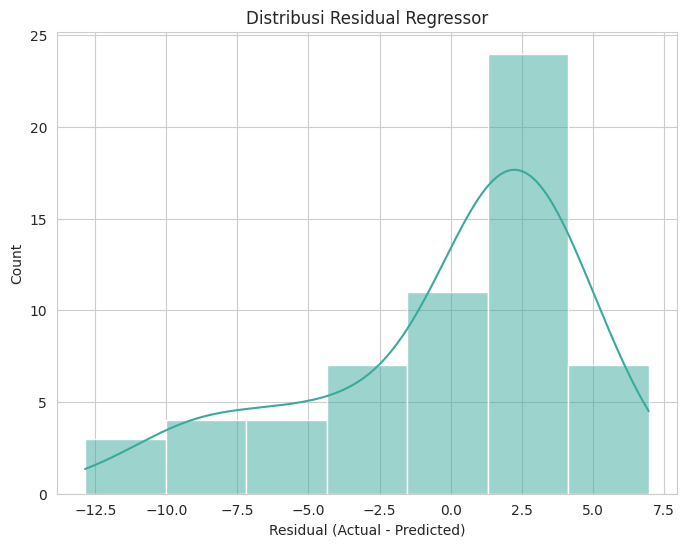


===== Cross-Validation Regressor =====
RMSE: 5.52 (+/- 0.80)
R²  : 0.6063 (+/- 0.0364)
Shape SHAP: (60, 19, 3)
Urutan kelas classifier: [np.str_('Netral'), np.str_('Rendah'), np.str_('Tinggi')]


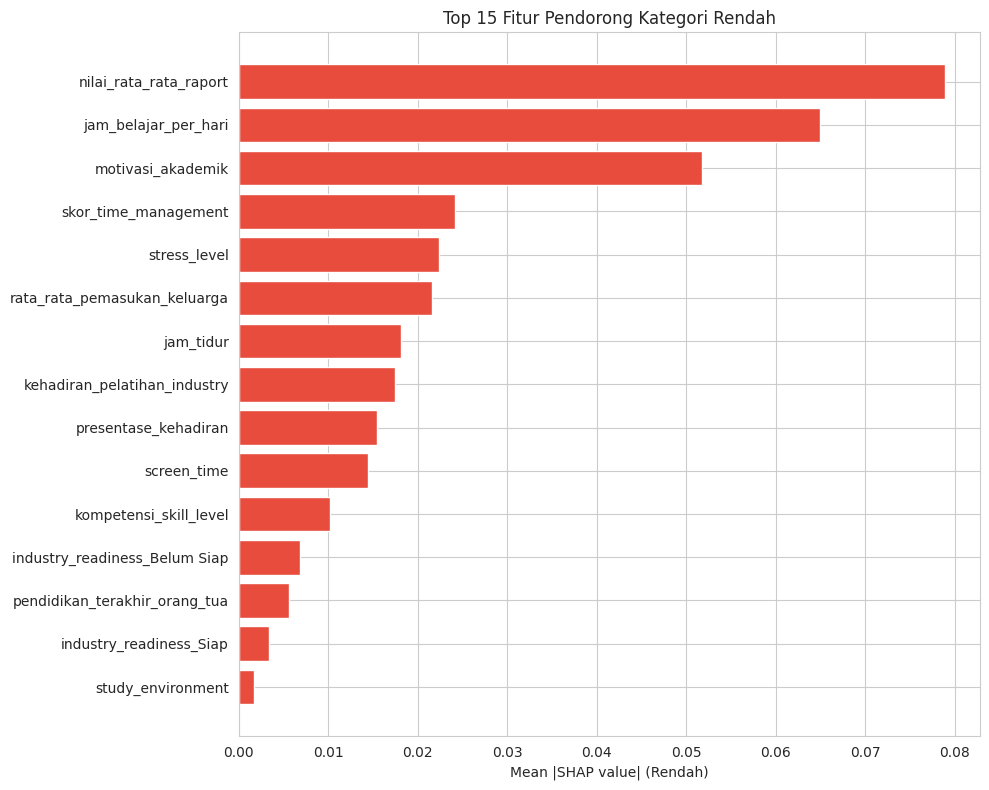


Model regressor, classifier, scaler, dan encoder berhasil disimpan.
Siap digunakan oleh backend Flask.


In [4]:
# -*- coding: utf-8 -*-
"""Random Forest Skripsi - SINTESA (Dual Model: Regressor + Classifier, 3 Kelas Absolut)

Dataset: data_300_siswa.csv (300 siswa, 17 variabel)
Kelas output: Rendah (≤70), Netral (71-85), Tinggi (>85) - threshold absolut.
Menangani imbalance dengan class_weight='balanced'.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, shap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================
# 1. Baca Data
# ============================================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_300_siswa.csv')
print("Dataset shape:", df.shape)
df = df.drop(columns=['nisn', 'nama_siswa', 'email'])

# ============================================
# 2. Missing Values
# ============================================
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# ============================================
# 3. Outlier Capping
# ============================================
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numeric_cols:
    if col != 'exam_score':
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = np.clip(df[col], lower, upper)

# ============================================
# 4. Encoding
# ============================================
ordinal_mappings = {
    'rata_rata_pemasukan_keluarga': ['< 2 Juta', '2 - 5 Juta', '5 - 10 Juta', '> 10 Juta'],
    'pendidikan_terakhir_orang_tua': ['SD', 'SMP', 'SMA/SMK', 'Diploma', 'Sarjana'],
    'study_environment': ['Kurang Kondusif', 'Cukup Kondusif', 'Kondusif'],
    'kompetensi_skill_level': ['Rendah', 'Menengah', 'Tinggi'],
    'stress_level': ['Rendah', 'Sedang', 'Berat']
}
nominal_cols = ['gender', 'kerja_sampingan', 'industry_readiness']

ordinal_encoders = {}
for col, cats in ordinal_mappings.items():
    oe = OrdinalEncoder(categories=[cats], dtype=int)
    df[col] = oe.fit_transform(df[[col]])
    ordinal_encoders[col] = oe

onehot_encoder_full = OneHotEncoder(sparse_output=False, drop=None)
onehot_encoded = onehot_encoder_full.fit_transform(df[nominal_cols])
onehot_feature_names = onehot_encoder_full.get_feature_names_out(nominal_cols)

df_encoded = df.drop(columns=nominal_cols)
df_onehot = pd.DataFrame(onehot_encoded, columns=onehot_feature_names, index=df.index)
df_final = pd.concat([df_encoded, df_onehot], axis=1)
print("Shape setelah encoding:", df_final.shape)

# ============================================
# 5. Fitur & Target (threshold absolut)
# ============================================
X = df_final.drop('exam_score', axis=1)
y_reg = df_final['exam_score']

# Definisi 3 kelas absolut
def get_abs_category(score):
    if score <= 70:
        return 'Rendah'
    elif score <= 85:
        return 'Netral'
    else:
        return 'Tinggi'

y_clf = np.array([get_abs_category(s) for s in y_reg])
RISK_CATEGORIES = ['Rendah', 'Netral', 'Tinggi']

feature_names = X.columns.tolist()

# ============================================
# 6. Split 80/20 (stratifikasi 3 kategori)
# ============================================
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print("Distribusi train:\n", pd.Series(y_train_clf).value_counts())
print("Distribusi test:\n", pd.Series(y_test_clf).value_counts())

# ============================================
# 7. Scaling
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 8. Regressor (dengan sample_weight jika perlu)
# ============================================
risk_binary = (y_train_reg < 70).astype(int)
if risk_binary.sum() > 0:
    class_counts = np.bincount(risk_binary)
    class_weights_reg = 1.0 / class_counts
    sample_weights = np.array([class_weights_reg[r] for r in risk_binary])
    sample_weights = sample_weights / sample_weights.sum() * len(sample_weights)
else:
    sample_weights = None

reg_no = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=5,
                               min_samples_leaf=2, max_features='sqrt', bootstrap=True,
                               oob_score=True, random_state=42)
if sample_weights is not None:
    reg_no.fit(X_train, y_train_reg, sample_weight=sample_weights)
else:
    reg_no.fit(X_train, y_train_reg)
y_pred_reg_no = reg_no.predict(X_test)

reg_scaled = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=5,
                                   min_samples_leaf=2, max_features='sqrt', bootstrap=True,
                                   oob_score=True, random_state=42)
if sample_weights is not None:
    reg_scaled.fit(X_train_scaled, y_train_reg, sample_weight=sample_weights)
else:
    reg_scaled.fit(X_train_scaled, y_train_reg)
y_pred_reg_scaled = reg_scaled.predict(X_test_scaled)

def eval_reg(y_true, y_pred):
    return {'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred),
            'R²': r2_score(y_true, y_pred)}

perf_no = eval_reg(y_test_reg, y_pred_reg_no)
perf_sc = eval_reg(y_test_reg, y_pred_reg_scaled)
print(f"Regresi Tanpa Scaler: RMSE={perf_no['RMSE']:.2f}, R²={perf_no['R²']:.4f}")
print(f"Regresi Dengan Scaler: RMSE={perf_sc['RMSE']:.2f}, R²={perf_sc['R²']:.4f}")

best_reg = reg_scaled if perf_sc['RMSE'] < perf_no['RMSE'] else reg_no
best_scaler_reg = scaler if perf_sc['RMSE'] < perf_no['RMSE'] else None
use_scaler_reg = perf_sc['RMSE'] < perf_no['RMSE']
y_pred_best_reg = y_pred_reg_scaled if use_scaler_reg else y_pred_reg_no

# ============================================
# 9. Classifier dengan class_weight='balanced'
# ============================================
clf_no = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5,
                                min_samples_leaf=2, max_features='sqrt', bootstrap=True,
                                oob_score=True, random_state=42, class_weight='balanced')
clf_no.fit(X_train, y_train_clf)
y_pred_clf_no = clf_no.predict(X_test)

clf_sc = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5,
                                min_samples_leaf=2, max_features='sqrt', bootstrap=True,
                                oob_score=True, random_state=42, class_weight='balanced')
clf_sc.fit(X_train_scaled, y_train_clf)
y_pred_clf_sc = clf_sc.predict(X_test_scaled)

def eval_clf_detail(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, labels=RISK_CATEGORIES, zero_division=0, output_dict=True)
    f1_macro = report['macro avg']['f1-score']
    return acc, f1_macro, report

acc_no, f1_no, _ = eval_clf_detail(y_test_clf, y_pred_clf_no)
acc_sc, f1_sc, _ = eval_clf_detail(y_test_clf, y_pred_clf_sc)
print(f"Classifier Tanpa Scaler: Akurasi={acc_no:.4f}, F1 Macro={f1_no:.4f}")
print(f"Classifier Dengan Scaler: Akurasi={acc_sc:.4f}, F1 Macro={f1_sc:.4f}")

best_clf = clf_sc if f1_sc > f1_no else clf_no
best_scaler_clf = scaler if f1_sc > f1_no else None
use_scaler_clf = f1_sc > f1_no
y_pred_best_clf = y_pred_clf_sc if use_scaler_clf else y_pred_clf_no
X_test_clf = X_test_scaled if use_scaler_clf else X_test.values

print("\n===== Classification Report Model Terbaik =====")
print(classification_report(y_test_clf, y_pred_best_clf, labels=RISK_CATEGORIES, zero_division=0))

# ============================================
# 10. Visualisasi Regressor
# ============================================
plt.figure(figsize=(8,6))
plt.scatter(y_test_reg, y_pred_best_reg, c='#1F6F5F', alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Regressor: Actual vs Predicted')
plt.grid(True)
plt.savefig('regressor_scatter.png', dpi=150)
plt.show()

errors = y_test_reg - y_pred_best_reg
plt.figure(figsize=(8,6))
sns.histplot(errors, kde=True, color='#3BA99C')
plt.title('Distribusi Residual Regressor')
plt.xlabel('Residual (Actual - Predicted)')
plt.savefig('residual_dist.png', dpi=150)
plt.show()

# ============================================
# 11. Cross-Validation (Regressor)
# ============================================
X_cv = X_train_scaled if use_scaler_reg else X_train
cv_rmse = cross_val_score(best_reg, X_cv, y_train_reg, cv=5, scoring='neg_root_mean_squared_error')
cv_r2 = cross_val_score(best_reg, X_cv, y_train_reg, cv=5, scoring='r2')
print("\n===== Cross-Validation Regressor =====")
print(f"RMSE: {-cv_rmse.mean():.2f} (+/- {cv_rmse.std():.2f})")
print(f"R²  : {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")

# ============================================
# 12. SHAP pada Classifier (kelas Rendah)
# ============================================
explainer_clf = shap.TreeExplainer(best_clf)
raw_shap = explainer_clf(X_test_clf)

if hasattr(raw_shap, 'values'):
    shap_array = raw_shap.values
else:
    shap_array = np.array(raw_shap)

print("Shape SHAP:", shap_array.shape)
n_features_shap = shap_array.shape[1]
if n_features_shap != len(feature_names):
    print(f"Warning: Jumlah fitur SHAP ({n_features_shap}) tidak cocok dengan feature_names ({len(feature_names)}).")
    feature_names_for_shap = [f"feature_{i}" for i in range(n_features_shap)]
else:
    feature_names_for_shap = feature_names

class_order = list(best_clf.classes_)
print("Urutan kelas classifier:", class_order)
rendah_idx = class_order.index('Rendah')   # kelas paling rendah

shap_rendah = shap_array[:, :, rendah_idx]

shap_importances_rendah = np.abs(shap_rendah).mean(axis=0)
importance_df_rendah = pd.DataFrame({
    'feature': feature_names_for_shap,
    'importance': shap_importances_rendah
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,8))
plt.barh(importance_df_rendah['feature'][:15][::-1], importance_df_rendah['importance'][:15][::-1], color='#E74C3C')
plt.xlabel('Mean |SHAP value| (Rendah)')
plt.title('Top 15 Fitur Pendorong Kategori Rendah')
plt.tight_layout()
plt.savefig('shap_importance_rendah.png', dpi=150)
plt.show()

shap_sample_clf = {
    "feature_names": feature_names_for_shap,
    "shap_values_class_rendah": shap_rendah[:10].tolist(),
    "expected_value": float(explainer_clf.expected_value[rendah_idx])
}
with open("shap_sample_classifier.json", "w") as f:
    json.dump(shap_sample_clf, f)

# ============================================
# 13. Simpan Model
# ============================================
joblib.dump(best_reg, 'random_forest_regressor.pkl')
joblib.dump(best_clf, 'random_forest_classifier.pkl')
if best_scaler_reg is not None:
    joblib.dump(best_scaler_reg, 'scaler_reg.pkl')
else:
    joblib.dump(None, 'scaler_reg.pkl')
if best_scaler_clf is not None:
    joblib.dump(best_scaler_clf, 'scaler_clf.pkl')
else:
    joblib.dump(None, 'scaler_clf.pkl')

encoders = {
    'ordinal_encoders': ordinal_encoders,
    'onehot_encoder': onehot_encoder_full,
    'nominal_cols': nominal_cols,
    'ordinal_mappings': ordinal_mappings,
    'feature_names': feature_names,
    'use_scaler_reg': use_scaler_reg,
    'use_scaler_clf': use_scaler_clf
}
joblib.dump(encoders, 'encoders.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

print("\nModel regressor, classifier, scaler, dan encoder berhasil disimpan.")
print("Siap digunakan oleh backend Flask.")